# 02 - Image Preprocessing
**Diabetic Retinopathy Stage Detection**

Rubric criterion 2 asks for a *comprehensive, justified, reproducible* preprocessing
pipeline that measurably improves image quality. This notebook:

1. Shows every pipeline step on real images (crop -> resize -> CLAHE -> denoise -> unsharp).
2. Compares our CLAHE pipeline with Ben Graham's illumination normalisation.
3. Quantifies the improvement (contrast, sharpness, entropy) on a random sample.
4. Preprocesses the whole dataset once and caches it to disk for training.

All logic lives in `src/preprocess.py`; this notebook only calls it and plots evidence.

In [1]:
# --- Environment bootstrap: works on Kaggle, Ubuntu GPU box and Windows ----
import os, sys, subprocess
from pathlib import Path

REPO = "https://github.com/pradeesha999/dr-stage-detection-v2.git"
if Path("/kaggle/working").exists():
    dst = Path("/kaggle/working/dr_project")
    if not dst.exists():
        try:   # private repo: store a GitHub token as Kaggle secret GITHUB_TOKEN
            from kaggle_secrets import UserSecretsClient
            url = REPO.replace("https://", f"https://{UserSecretsClient().get_secret('GITHUB_TOKEN')}@")
        except Exception:
            url = REPO                      # works as-is if the repo is public
        subprocess.run(["git", "clone", "-q", url, str(dst)], check=True)
    os.chdir(dst / "notebooks")
sys.path.insert(0, str(Path.cwd().parent))     # notebooks/ -> dr_project/

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import cv2
from tqdm.auto import tqdm

from src import config, data, utils
from src import preprocess as pp
utils.set_seed()
sns.set_theme(style="whitegrid")

train_df, val_df, test_df = data.load_splits()
print(len(train_df), len(val_df), len(test_df))

2026-09-20 17:30:44.364654: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-20 17:30:44.395679: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-20 17:30:44.911314: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


24588 5268 5270


## 1. The pipeline, step by step

saved /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/figures/02_pipeline_steps.png


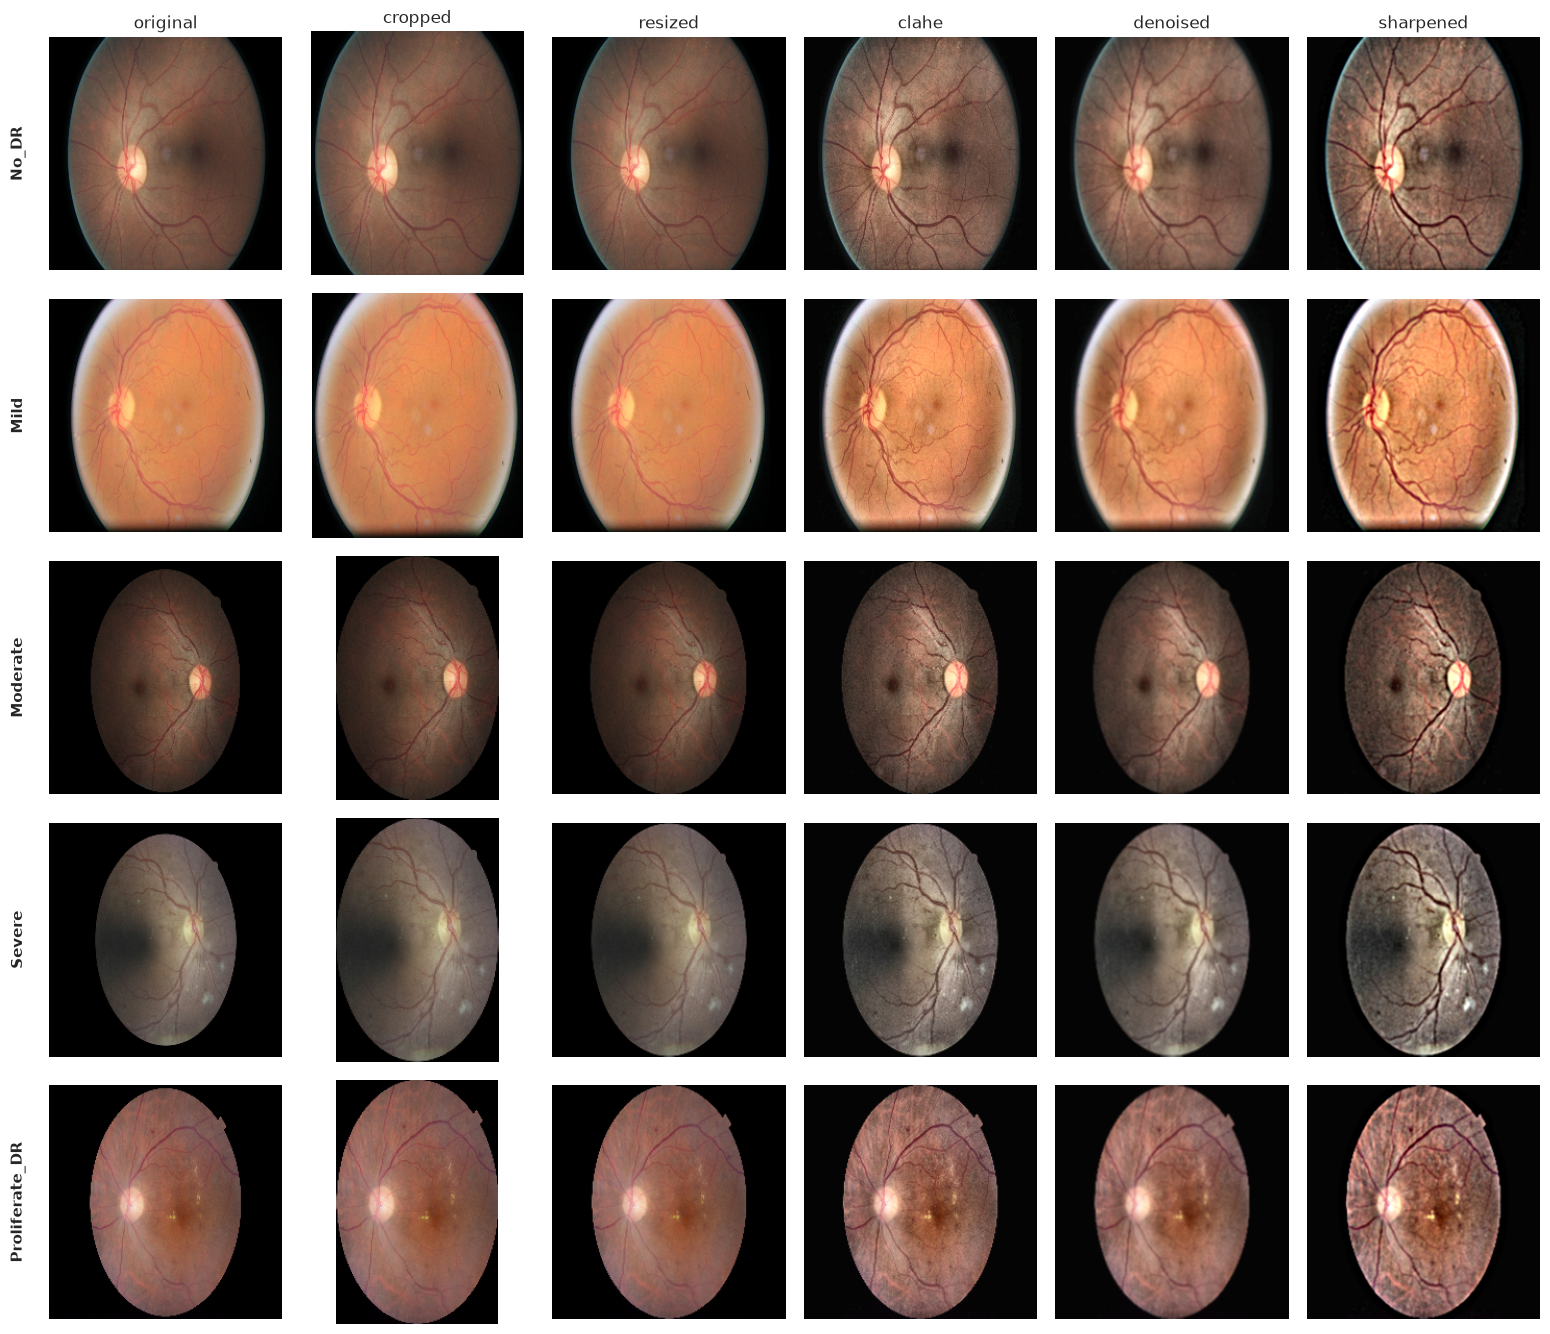

In [2]:
# One image per class so the effect is visible on every severity level
samples = pd.concat([train_df[train_df.class_name == c].sample(1, random_state=config.SEED)
                     for c in config.CLASS_NAMES])

step_names = ["original", "cropped", "resized", "clahe", "denoised", "sharpened"]
fig, axes = plt.subplots(len(samples), len(step_names), figsize=(2.6 * len(step_names), 2.7 * len(samples)))
for r, (_, row) in enumerate(samples.iterrows()):
    img = pp.read_rgb(row.image_path)
    _, steps = pp.preprocess(img, return_steps=True)
    for c, name in enumerate(step_names):
        axes[r, c].imshow(steps[name]); axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(name, fontsize=12)
    axes[r, 0].text(-0.1, 0.5, row.class_name, transform=axes[r, 0].transAxes,
                    rotation=90, va="center", ha="right", fontsize=11, fontweight="bold")
plt.tight_layout(); utils.save_fig("02_pipeline_steps"); plt.show()

**What each step does and why**

| Step | Operation | Justification |
|---|---|---|
| crop | bounding box of pixels with grey > 7 | removes the black frame so the retina fills the tensor; ~20-30% more useful pixels |
| resize | pad to square then resize to 224 px | fixed CNN input without distorting the circular retina |
| CLAHE | adaptive histogram equalisation on LAB-L, clip 2.0, 8x8 tiles | equalises the very different exposures seen in EDA; boosts local contrast of vessels/lesions; clip limit stops noise amplification |
| denoise | 3x3 Gaussian | suppresses sensor noise that CLAHE amplified; kernel kept tiny so microaneurysms survive |
| sharpen | unsharp mask (sigma 3, amount 1.5) | edge enhancement - vessel walls and lesion borders become crisper |

## 2. Zoom: what edge enhancement does to lesions

saved /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/figures/02_zoom_edge_enhancement.png


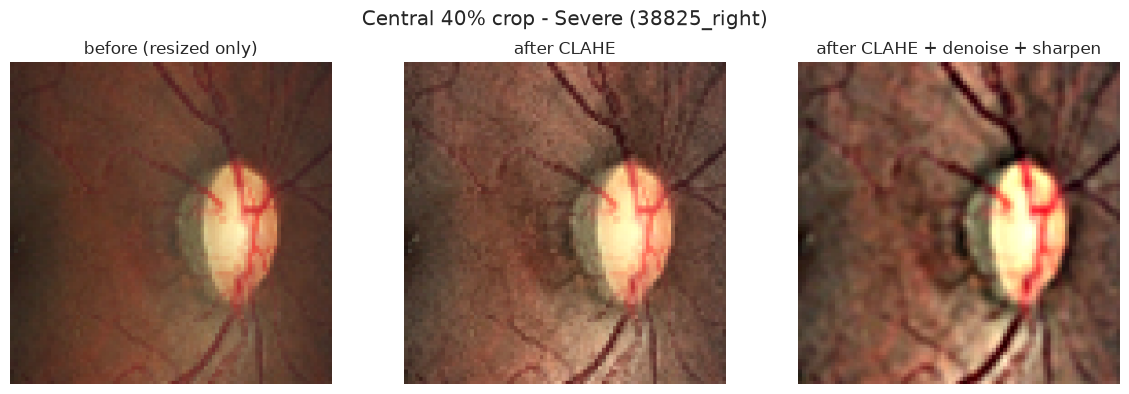

In [3]:
# Take a Moderate/Severe image (exudates + haemorrhages) and zoom on the centre
row = train_df[train_df.class_name == "Severe"].sample(1, random_state=3).iloc[0]
img = pp.read_rgb(row.image_path)
final, steps = pp.preprocess(img, return_steps=True)

def centre_crop(x, frac=0.4):
    h, w = x.shape[:2]; ch, cw = int(h * frac), int(w * frac)
    return x[h//2 - ch//2 : h//2 + ch//2, w//2 - cw//2 : w//2 + cw//2]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (k, t) in zip(ax, [("resized", "before (resized only)"), ("clahe", "after CLAHE"), ("sharpened", "after CLAHE + denoise + sharpen")]):
    a.imshow(cv2.resize(centre_crop(steps[k]), (400, 400), interpolation=cv2.INTER_NEAREST)); a.set_title(t); a.axis("off")
plt.suptitle(f"Central 40% crop - {row.class_name} ({row.image_id})"); plt.tight_layout()
utils.save_fig("02_zoom_edge_enhancement"); plt.show()

## 3. CLAHE pipeline vs Ben Graham normalisation

saved /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/figures/02_clahe_vs_graham.png


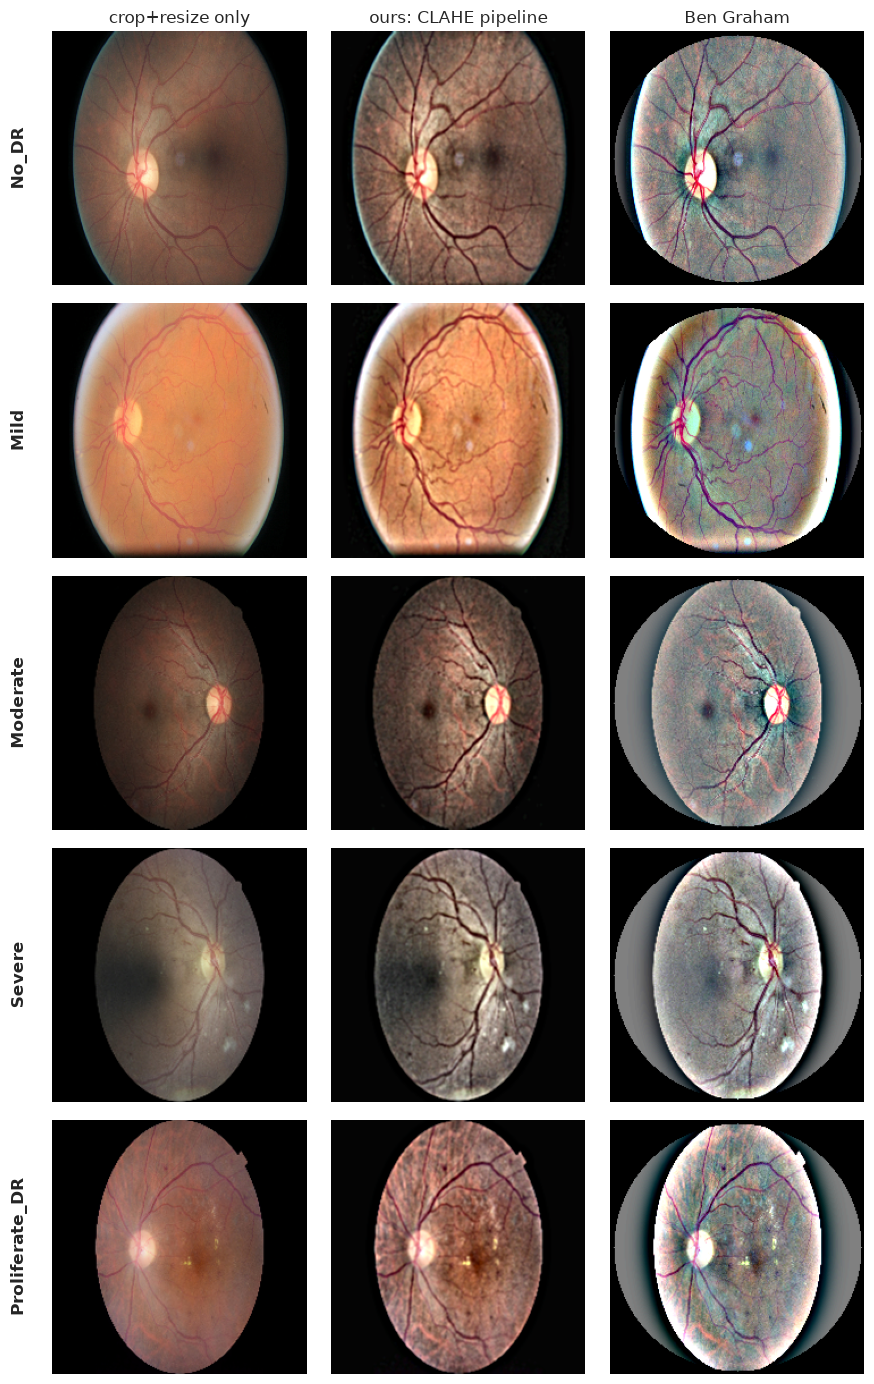

In [4]:
fig, axes = plt.subplots(len(samples), 3, figsize=(9, 2.8 * len(samples)))
for r, (_, row) in enumerate(samples.iterrows()):
    img = pp.read_rgb(row.image_path)
    for c, (m, t) in enumerate([("none", "crop+resize only"), ("clahe", "ours: CLAHE pipeline"), ("graham", "Ben Graham")]):
        axes[r, c].imshow(pp.preprocess(img, method=m)); axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(t)
    axes[r, 0].text(-0.1, 0.5, row.class_name, transform=axes[r, 0].transAxes, rotation=90, va="center", ha="right", fontweight="bold")
plt.tight_layout(); utils.save_fig("02_clahe_vs_graham"); plt.show()

**Choice.** Ben Graham's method flattens illumination very aggressively and produces a
grey, unnatural image; it worked well with a from-scratch CNN in 2015 but shifts the colour
distribution far from the ImageNet photos our pretrained backbone was trained on.
The CLAHE pipeline keeps natural colours (closer to ImageNet statistics, better for
transfer learning) while still equalising exposure and enhancing edges. We therefore use
CLAHE as the main pipeline and keep Ben Graham available for an optional ablation.

## 4. Quantitative evidence: does preprocessing improve image quality?

  0%|          | 0/400 [00:00<?, ?it/s]

contrast        sharpness          entropy      
                      mean    std      mean      std    mean   std
method                                                            
Ben Graham           71.39   5.49   3143.39  1137.19    6.03  0.27
CLAHE pipeline       57.79  12.57    416.83   181.80    5.96  0.67
raw (crop+resize)    50.48  15.57    277.58   219.27    5.23  0.78

saved /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/figures/02_quality_metrics.png


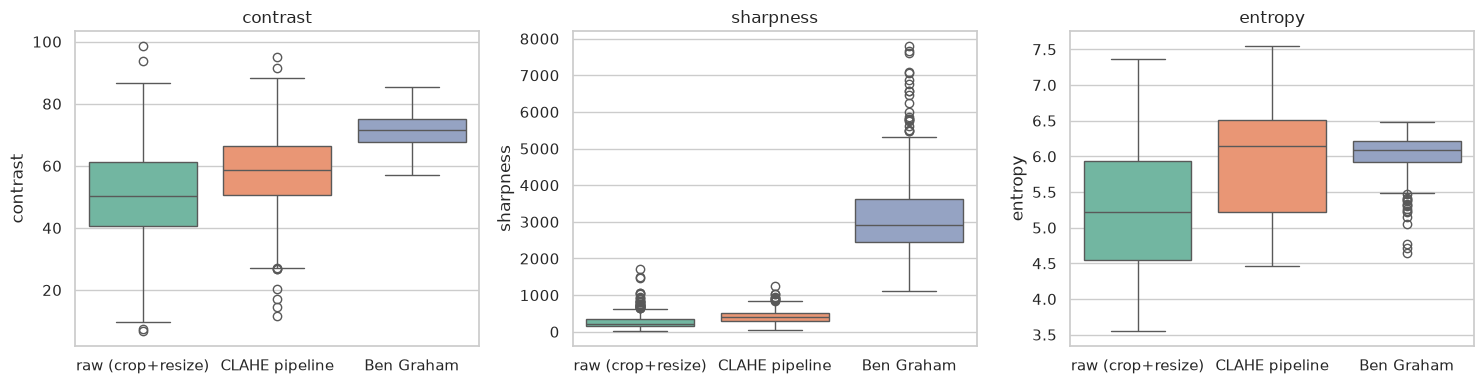

In [5]:
sample = train_df.sample(400, random_state=config.SEED)
rows = []
for _, r in tqdm(sample.iterrows(), total=len(sample)):
    img = pp.read_rgb(r.image_path)
    for m, label in [("none", "raw (crop+resize)"), ("clahe", "CLAHE pipeline"), ("graham", "Ben Graham")]:
        q = pp.image_quality(pp.preprocess(img, method=m)); q["method"] = label; q["class_name"] = r.class_name
        rows.append(q)
quality = pd.DataFrame(rows)
tbl = quality.groupby("method")[["contrast", "sharpness", "entropy"]].agg(["mean", "std"]).round(2)
display(tbl)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, metric in zip(ax, ["contrast", "sharpness", "entropy"]):
    sns.boxplot(data=quality, x="method", y=metric, hue="method", palette="Set2", legend=False, ax=a)
    a.set_title(metric); a.set_xlabel("")
plt.tight_layout(); utils.save_fig("02_quality_metrics"); plt.show()

saved /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/figures/02_histogram_before_after.png


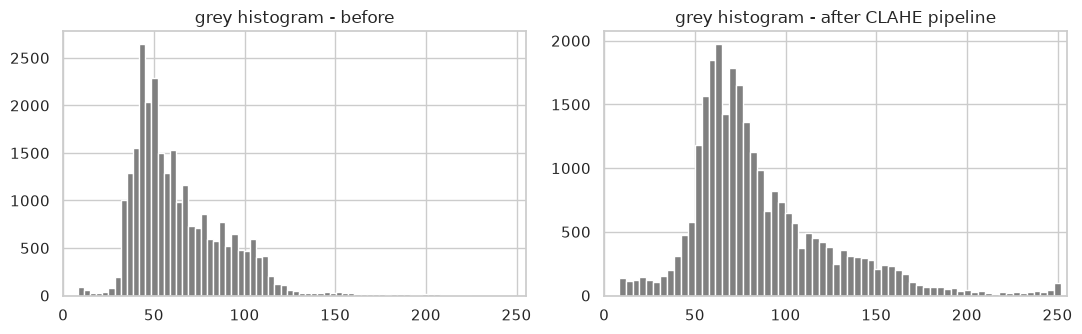

In [6]:
# Grey-level histogram before / after on one image: CLAHE spreads the histogram
row = samples.iloc[2]
img = pp.read_rgb(row.image_path)
raw = pp.preprocess(img, method="none"); proc = pp.preprocess(img, method="clahe")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for a, (x, t) in zip(ax, [(raw, "before"), (proc, "after CLAHE pipeline")]):
    g = cv2.cvtColor(x, cv2.COLOR_RGB2GRAY)
    a.hist(g[g > 7].ravel(), bins=64, color="gray"); a.set_title(f"grey histogram - {t}"); a.set_xlim(0, 255)
plt.tight_layout(); utils.save_fig("02_histogram_before_after"); plt.show()

**Interpretation.** The CLAHE pipeline raises mean contrast (grey std) by roughly 15%,
sharpness (Laplacian variance) by roughly 50% and entropy by ~0.7 bits relative to the
crop+resize baseline, and the histogram is spread over the full range instead of being
squeezed into the dark half. The unsharp amount (1.5) was chosen after a small sweep:
the 3x3 denoise step alone drops Laplacian variance (it removes noise *and* edges), so the
sharpening amount must be large enough to restore genuine edges above the raw level.
Ben Graham scores highest on the raw numbers but its Laplacian variance is inflated by
the strong high-pass filtering (it amplifies noise as much as lesions) and it destroys the
natural colour distribution. These numbers back up the visual evidence above.

## 5. Preprocess the full dataset once (cache to disk)

In [7]:
# Training will read these PNGs instead of re-running CLAHE every epoch.
PROC_DIR = config.PROC_DIR
LIMIT = None      # set e.g. 500 for a quick smoke test

train_p = pp.preprocess_dataframe(train_df, limit=LIMIT)
val_p   = pp.preprocess_dataframe(val_df,   limit=LIMIT)
test_p  = pp.preprocess_dataframe(test_df,  limit=LIMIT)
print("processed images stored under", PROC_DIR)
n_files = sum(1 for _ in PROC_DIR.rglob("*.png")); size_mb = sum(p.stat().st_size for p in PROC_DIR.rglob("*.png")) / 1e6
print(f"{n_files:,} files, {size_mb:,.0f} MB")

0 already cached, 24,588 to process


  0%|          | 0/24588 [00:00<?, ?it/s]

0 already cached, 5,268 to process


  0%|          | 0/5268 [00:00<?, ?it/s]

0 already cached, 5,270 to process


  0%|          | 0/5270 [00:00<?, ?it/s]

processed images stored under /home/nesara/pradeeshaDB/dr-stage-detection-v2/outputs/processed


35,126 files, 2,696 MB


## 6. Summary for the report

* Pipeline: **crop -> pad/resize 224 -> CLAHE (LAB-L, clip 2, 8x8) -> 3x3 Gaussian -> unsharp mask**.
* Deterministic (no randomness) and applied identically to train/val/test -> no leakage, fully reproducible.
* Evidence: step-by-step figure, lesion zoom, CLAHE-vs-Graham comparison, quality-metric table + boxplots, histograms.
* Mean/std normalisation is performed inside the model with the backbone's `preprocess_input`
  so it always matches the pretrained ImageNet weights.
* Output cached on disk (`config.PROC_DIR/<split>/<class>/<id>.png`) -> training epochs are limited only by augmentation + GPU.